<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/04%20-%20preprocesado1%20sin%20eliminar%20NaN%20para%20test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

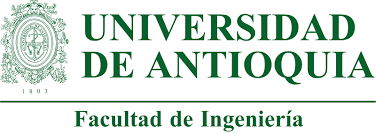

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega Final "Preprocesado_1 Sin Eliminar `NAN` para `test`"** </font>

## <font color='157699'> **Paso 1:** </font>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [2]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download --force udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 1.40GB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [3]:
!unzip udea*.zip > /dev/null

In [4]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  59185238 test.csv
   692501  10666231 143732437 train.csv
  1286075  15528571 207634348 total


## <font color='157699'> **Paso 4: Se carga `train.csv` con la librería `Pandas`** </font>

In [5]:
import pandas as pd
import numpy as np

z = pd.read_csv("test.csv")
print ("shape of loaded dataframe", z.shape)

shape of loaded dataframe (296786, 20)


In [6]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


**Información general**

Considerando que se tiene en total 692K elementos de datos, se tiene relativamente pocos valores faltantes en cada columna.

In [7]:
z.isna().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,2723
E_HORASSEMANATRABAJA,13379
F_ESTRATOVIVIENDA,13795
F_TIENEINTERNET,11539
F_EDUCACIONPADRE,9993
F_TIENELAVADORA,17259


In [8]:
z.dtypes

,0
ID,int64
PERIODO_ACADEMICO,int64
E_PRGM_ACADEMICO,object
E_PRGM_DEPARTAMENTO,object
E_VALORMATRICULAUNIVERSIDAD,object
E_HORASSEMANATRABAJA,object
F_ESTRATOVIVIENDA,object
F_TIENEINTERNET,object
F_EDUCACIONPADRE,object
F_TIENELAVADORA,object


**Revisión de columnas**

**Periodo**

**Tratamiendo de columna: Eliminación**

In [9]:
z = z.drop(columns=['PERIODO_ACADEMICO'])

In [10]:
z.head()

,ID,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


**Programa Academico**

In [11]:
del z["E_PRGM_ACADEMICO"]

In [12]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


**Departamento**

In [13]:
len(z.E_PRGM_DEPARTAMENTO.unique())

31

**Tratamiendo de columna: Variable nominal**

In [14]:
#Se eliminan los espacios para poder acceder a la variables asi: z.EL_DEPARTAMENTO
z['E_PRGM_DEPARTAMENTO'] = z['E_PRGM_DEPARTAMENTO'].str.replace(' ', '_')
sorted(z.E_PRGM_DEPARTAMENTO.unique())

['AMAZONAS',
 'ANTIOQUIA',
 'ARAUCA',
 'ATLANTICO',
 'BOGOTÁ',
 'BOLIVAR',
 'BOYACA',
 'CALDAS',
 'CAQUETA',
 'CASANARE',
 'CAUCA',
 'CESAR',
 'CHOCO',
 'CORDOBA',
 'CUNDINAMARCA',
 'GUAVIARE',
 'HUILA',
 'LA_GUAJIRA',
 'MAGDALENA',
 'META',
 'NARIÑO',
 'NORTE_SANTANDER',
 'PUTUMAYO',
 'QUINDIO',
 'RISARALDA',
 'SANTANDER',
 'SAN_ANDRES',
 'SUCRE',
 'TOLIMA',
 'VALLE',
 'VAUPES']

**OneHot**

In [15]:
df_onehot = pd.get_dummies(z['E_PRGM_DEPARTAMENTO'], prefix='DEP')
z = pd.concat([z, df_onehot], axis=1)

In [16]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,...,False,False,False,False,False,False,True,False,False,False
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False


In [17]:
z.drop(columns=['E_PRGM_DEPARTAMENTO'], inplace=True)

In [18]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Decisiones de las columnas con NAN**

**Con el precio de la matricula**

**Tratamiento de la columna: Variable ordinal**

In [19]:
cmap = {'No pagó matrícula': 0,
        'Menos de 500 mil': 1,
        'Entre 500 mil y menos de 1 millón': 2,
        'Entre 1 millón y menos de 2.5 millones': 3,
        'Entre 2.5 millones y menos de 4 millones': 4,
        'Entre 4 millones y menos de 5.5 millones': 5,
        'Entre 5.5 millones y menos de 7 millones': 6,
        'Más de 7 millones': 7}

z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)

z.E_VALORMATRICULAUNIVERSIDAD.value_counts()
z.head()

/tmp/ipython-input-1439519292.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)


,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Tratamiento de los NaN: Distribución de probabilidad**

In [20]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(296786, np.int64(2723), np.float64(0.009174961083069956))

In [21]:
# Calcular la distribución de probabilidad de los valores existentes
prob_dist = z['E_VALORMATRICULAUNIVERSIDAD'].value_counts(normalize=True)

# Rellenar los valores NaN usando la distribución de probabilidad
z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].apply(
    lambda x: np.random.choice(prob_dist.index, p=prob_dist.values) if pd.isna(x) else x
)

# Verificar que no queden valores NaN
print(z['E_VALORMATRICULAUNIVERSIDAD'].isna().sum())

0


In [22]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(296786, np.int64(0), np.float64(0.0))

**Con las horas semanales trabajadas por los estudiantes**

In [23]:
z.E_HORASSEMANATRABAJA.unique()

array(['Menos de 10 horas', 'Entre 21 y 30 horas', '0',
       'Entre 11 y 20 horas', 'Más de 30 horas', nan], dtype=object)

In [24]:
z.E_HORASSEMANATRABAJA.isna().sum()/z.shape[0]

np.float64(0.04507961965860923)

**Tratamiento de la columna: Variable ordinal**

In [25]:
# Defino el orden para los valores ordinales
horas_trabajo_mapping = {
        '0': 0,
        'Menos de 10 horas': 1,
        'Entre 11 y 20 horas': 2,
        'Entre 21 y 30 horas': 3,
        'Más de 30 horas': 4
    }

# Convierto la columna en tipo categórico ordinal
z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)
z.E_HORASSEMANATRABAJA.value_counts()

# Verifico los cambios
print(z['E_HORASSEMANATRABAJA'].value_counts())
z.E_HORASSEMANATRABAJA.unique()

E_HORASSEMANATRABAJA
4.0    106189
0.0     50422
2.0     49386
3.0     39931
1.0     37479
Name: count, dtype: int64


/tmp/ipython-input-3103409500.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)


array([ 1.,  3.,  0.,  2.,  4., nan])

**Tratamiento de los NaN: Moda**

In [26]:
# Reemplazo los valores NaN con la moda
moda = z['E_HORASSEMANATRABAJA'].mode()[0]
z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)
print(moda)

4.0


/tmp/ipython-input-2723976017.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)


In [27]:
z.E_HORASSEMANATRABAJA.head()

,E_HORASSEMANATRABAJA
0,1.0
1,3.0
2,0.0
3,3.0
4,2.0


**Con el estrato de vivienda**

In [28]:
z.F_ESTRATOVIVIENDA.unique()

array(['Estrato 3', 'Estrato 2', 'Estrato 1', 'Estrato 4', nan,
       'Estrato 6', 'Estrato 5', 'Sin Estrato'], dtype=object)

In [29]:
z.F_ESTRATOVIVIENDA.isna().sum(),z.F_ESTRATOVIVIENDA.isna().sum()/z.shape[0]

(np.int64(13795), np.float64(0.04648130302642308))

In [30]:
z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0], (z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0])/z.shape[0]

(np.int64(15219), np.float64(0.051279373016247395))

**Tratamiento de la columna: Variable ordinal**

In [31]:
estrato_mapping = {
    'Estrato 1': 1,
    'Estrato 2': 2,
    'Estrato 3': 3,
    'Estrato 4': 4,
    'Estrato 5': 5,
    'Estrato 6': 6
}

# Reemplazamos los valores categóricos por los numéricos
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace(estrato_mapping)

**Tratamiento de los NaN: Distribución de probabilidad**

In [32]:
# Paso 1: Reemplazar "Sin Estrato" con NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)

# Paso 2: Rellenar los NaN aleatoriamente usando una distribución de probabilidad
# Obtener los valores sin NaN
non_nan_values = z['F_ESTRATOVIVIENDA'].dropna()

# Probabilidades según la frecuencia de aparición
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].apply(fill_random)

/tmp/ipython-input-3124771742.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)


In [33]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Con el hecho de tener internet o no**

In [34]:
z.F_TIENEINTERNET.unique()

array(['Si', 'No', nan], dtype=object)

In [35]:
z.F_TIENEINTERNET.isna().sum(),z.F_TIENEINTERNET.isna().sum()/z.shape[0]

(np.int64(11539), np.float64(0.038879866300971073))

In [36]:
len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "Si"]), len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "No"])

(254075, 31172)

**Tratamiento de la columna: Variable ordinal**

In [37]:
# Defino el orden para los valores ordinales
tiene_internet_mapping = {
        'No': 0,
        'Si': 1
    }

# Convierto la columna en tipo categórico ordinal
z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)
z.F_TIENEINTERNET.value_counts()

# Verifico los cambios
print(z['F_TIENEINTERNET'].value_counts())
z.F_TIENEINTERNET.unique()

F_TIENEINTERNET
1.0    254075
0.0     31172
Name: count, dtype: int64


/tmp/ipython-input-2150935816.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)


array([ 1.,  0., nan])

**Tratamiento de los NaN: Distribución de probabilidad.**

In [38]:
# Calcular la distribución de probabilidad de los valores existentes
prob_dist_internet = z['F_TIENEINTERNET'].value_counts(normalize=True)

# Rellenar los valores NaN usando la distribución de probabilidad
z['F_TIENEINTERNET'] = z['F_TIENEINTERNET'].apply(
    lambda x: np.random.choice(prob_dist_internet.index, p=prob_dist_internet.values) if pd.isna(x) else x
)

# Verificar que no queden valores NaN
print(z['F_TIENEINTERNET'].isna().sum())

0


**Educación padre**

In [39]:
z.F_EDUCACIONPADRE.unique()

array(['Técnica o tecnológica completa',
       'Secundaria (Bachillerato) completa',
       'Secundaria (Bachillerato) incompleta', 'Primaria incompleta',
       'Ninguno', 'Primaria completa', 'Postgrado', nan,
       'Educación profesional completa',
       'Técnica o tecnológica incompleta',
       'Educación profesional incompleta', 'No sabe', 'No Aplica'],
      dtype=object)

In [40]:
z.F_EDUCACIONPADRE.isna().sum(),z.F_EDUCACIONPADRE.isna().sum()/z.shape[0]

(np.int64(9993), np.float64(0.03367072570808596))

In [41]:
z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0], (z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(21014), np.float64(0.07080522666163498))

**Tratamiento de la columna: Variable ordinal**

In [42]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


In [43]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-2210987325.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [44]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONPADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].apply(fill_nan_random)

In [45]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Educación madre**

In [46]:
z.F_EDUCACIONMADRE.unique()

array(['Primaria completa', 'Técnica o tecnológica completa',
       'Secundaria (Bachillerato) completa', 'Primaria incompleta',
       'Postgrado', 'Secundaria (Bachillerato) incompleta', nan,
       'Ninguno', 'Educación profesional completa',
       'Técnica o tecnológica incompleta',
       'Educación profesional incompleta', 'No sabe', 'No Aplica'],
      dtype=object)

In [47]:
z.F_EDUCACIONMADRE.isna().sum(),z.F_EDUCACIONMADRE.isna().sum()/z.shape[0]

(np.int64(10223), np.float64(0.03444569487779073))

In [48]:
z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0], (z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(12294), np.float64(0.04142378683630629))

In [49]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Tratamiento de la columna: Variable ordinal**

In [50]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-1612714866.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [51]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONMADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].apply(fill_nan_random)

In [52]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Pago su propia matricula**

In [53]:
z.E_PAGOMATRICULAPROPIO.unique()

array(['Si', 'No', nan], dtype=object)

In [54]:
z.E_PAGOMATRICULAPROPIO.isna().sum(),z.E_PAGOMATRICULAPROPIO.isna().sum()/z.shape[0]

(np.int64(2807), np.float64(0.009457993301570829))

In [55]:
z.E_PAGOMATRICULAPROPIO.value_counts()

,count
E_PAGOMATRICULAPROPIO,
No,163869
Si,130110


**Tratamiento de los NaN: Distribución de probabilidad**

In [56]:
# Calcular la distribución de probabilidad de los valores existentes
prob_dist_pago_matricula = z['E_PAGOMATRICULAPROPIO'].value_counts(normalize=True)

# Rellenar los valores NaN usando la distribución de probabilidad
z['E_PAGOMATRICULAPROPIO'] = z['E_PAGOMATRICULAPROPIO'].apply(
    lambda x: np.random.choice(prob_dist_pago_matricula.index, p=prob_dist_pago_matricula.values) if pd.isna(x) else x
)

# Verificar que no queden valores NaN
print(z['E_PAGOMATRICULAPROPIO'].isna().sum())

0


**Tratamiento de la columna: Variable nominal**


**OneHot**

In [57]:
df_onehot = pd.get_dummies(z['E_PAGOMATRICULAPROPIO'], prefix='PAGOMATRICULAPROPIO')
z = pd.concat([z, df_onehot], axis=1)

In [58]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,True
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,True,False,False,False,True,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False


In [59]:
z.drop(columns=['E_PAGOMATRICULAPROPIO'], inplace=True)
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,True
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,True,False,False,False,True,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False


In [60]:
z.replace([False], 0, inplace=True)
z.replace([True], 1, inplace=True)

/tmp/ipython-input-1347985908.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z.replace([True], 1, inplace=True)


In [61]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,0,1
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,0,0,0,0,1,0,0,0,1,0
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0


In [62]:
z.shape

(296786, 49)

In [63]:
z.to_csv('preprocesamiento_1.csv', index=False)